# Phase 2 — Marchenko–Pastur Validation (Experiment 1)

**Goal:** show that the *bulk* of the empirical eigenvalue distribution is well described
by the Marchenko–Pastur density for pure noise, and quantify the agreement with an
honestly calibrated Kolmogorov–Smirnov test. Produces **Figure 1** of the paper and the
results of **Section 5.1**.

## The density and its parameters

$$f_{\sigma^2}(\lambda) = \frac{\sqrt{(\lambda_+ - \lambda)(\lambda - \lambda_-)}}
{2\pi\, q\, \sigma^2 \lambda},\qquad
\lambda_\pm = \sigma^2(1 \pm \sqrt q\,)^2 .$$

Although standardization makes the *total* variance exactly 1 per stock, the bulk does
**not** sit at $\sigma^2 = 1$: the signal modes absorb a large share of the trace,
and trace conservation compresses the noise bulk to an effective variance
$\sigma^2_{\mathrm{eff}} < 1$ (Phase 1 found 41 eigenvalues *below* the naive band for
exactly this reason). Following Laloux et al. (1999) we therefore treat $\sigma^2$ as a
parameter, determined two ways:

1. **Market-mode convention (analytic):** $\sigma^2_{\mathrm{mkt}} = 1 - \lambda_1/N$ —
   remove only the variance of the undisputed market mode. (The fully self-consistent
   alternative, $\sigma^2 = 1 - \sum_{\lambda_i>\lambda_+}\lambda_i/N$ iterated to a fixed
   point, turns out to be *unstable* on our data — shrinking the band promotes more
   eigenvalues to "signal", which shrinks the band further, and the iteration runs away.
   We report this: it is evidence that the spectrum has no sharp spike/bulk separation
   but a shoulder of sector modes grading into the bulk.)
2. **Best fit:** $\hat\sigma^2 = \arg\min_{\sigma^2} D(\sigma^2)$, where $D$ is the KS
   distance between the empirical CDF of the bulk (all $\lambda_i \le \lambda_+(\sigma^2)$ —
   below-band mass is *penalized*, not hidden) and the MP CDF.

The two differ by construction (the best fit is free to reclassify the shoulder as
signal); we show the full profile $D(\sigma^2)$ so the trade-off is explicit rather
than hidden in a point estimate, and we carry **both** resulting thresholds
$\lambda_+$ into the filtering phase as primary/robustness variants.

## Why the naive KS p-value is invalid — and what we do instead

Two violations of textbook KS assumptions: (i) eigenvalues are strongly dependent
(level repulsion), not an i.i.d. sample; (ii) $\sigma^2$ is estimated from the same data
(a Lilliefors-type violation, anti-conservative). We therefore report the naive p-value
only for reference and calibrate $D$ by Monte Carlo under two nulls, **re-running the
entire fitting procedure on every simulated draw**:

- **Gaussian–Wishart null:** $\tilde R_{\mathrm{sim}} \sim \mathcal N(0,1)$ i.i.d.,
  same $T \times N$, columns standardized like the real pipeline.
- **Permutation null:** each column of the *real* $\tilde R$ independently shuffled in
  time — destroys all cross-correlation, keeps every stock's fat-tailed marginal exactly.
  This tests "no cross-sectional dependence" without assuming Gaussianity.

$p_{\mathrm{MC}} = \Pr(D_{\mathrm{null}} \ge D_{\mathrm{obs}})$.

In [1]:
from pathlib import Path
import json, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kstwo

DATA_DIR = Path("data")
PALETTE = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9"]
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "font.size": 10, "axes.titlesize": 11,
})

ev = np.load(DATA_DIR / "eigen_phase1.npz", allow_pickle=True)
lam, q, T, N = ev["lam"], float(ev["q"]), int(ev["T"]), int(ev["N"])
Rs = pd.read_parquet(DATA_DIR / "returns_std.parquet").values
print(f"N={N}, T={T}, q={q:.4f}; lam[0]={lam[0]:.1f}, lam[-1]={lam[-1]:.4f}")

def mp_edges(s2, q=q):
    sq = np.sqrt(q)
    return s2 * (1 - sq)**2, s2 * (1 + sq)**2

def mp_cdf_grid(s2, q=q, npts=1500):
    # returns (grid, CDF values) of the MP law with variance s2 on its support
    lo, hi = mp_edges(s2, q)
    x = np.linspace(lo, hi, npts)
    with np.errstate(invalid="ignore"):
        pdf = np.sqrt(np.maximum((hi - x) * (x - lo), 0)) / (2 * np.pi * q * s2 * x)
    cdf = np.concatenate([[0], np.cumsum((pdf[1:] + pdf[:-1]) * np.diff(x) / 2)])
    return x, cdf / cdf[-1]          # renormalize the numerical quadrature

def ks_bulk(evals, s2, q=q):
    # KS distance between the bulk (all eigenvalues <= lam_+) and the MP CDF.
    # Eigenvalues below lam_- contribute distance (F_MP = 0 there): nothing is hidden.
    lo, hi = mp_edges(s2, q)
    bulk = np.sort(evals[evals <= hi])
    n = len(bulk)
    if n < 10:
        return np.inf, n
    x, cdf = mp_cdf_grid(s2, q)
    F = np.interp(bulk, x, cdf, left=0.0, right=1.0)
    i = np.arange(1, n + 1)
    D = max(np.max(i / n - F), np.max(F - (i - 1) / n))
    return D, n

S2_GRID = np.arange(0.40, 1.1005, 0.002)   # same grid for real data and every MC draw

def fit_sigma2(evals):
    Ds = np.array([ks_bulk(evals, s2)[0] for s2 in S2_GRID])
    j = int(np.argmin(Ds))
    return S2_GRID[j], Ds[j]

N=548, T=1236, q=0.4434; lam[0]=130.2, lam[-1]=0.0433


## 1. Candidate noise bands and the $D(\sigma^2)$ profile

Naive ($\sigma^2=1$), the market-mode convention, and the KS-optimal fit — with band
edges, eigenvalue counts, and the KS distance each implies. The self-consistent
iteration is run first purely to document its instability.

In [2]:
# self-consistent iteration: documented as unstable, not used
s2_fp, trail = 1.0, []
for it in range(60):
    _, hi = mp_edges(s2_fp)
    s2_new = 1.0 - lam[lam > hi].sum() / N
    trail.append(s2_new)
    if abs(s2_new - s2_fp) < 1e-12:
        break
    s2_fp = s2_new
print(f"self-consistent iteration: {' -> '.join(f'{v:.3f}' for v in trail[:6])} ... "
      f"-> {trail[-1]:.3f}  (runaway: no stable spike/bulk separation)")

s2_mkt = 1.0 - lam[0] / N          # market-mode convention

# best fit + full profile
t0 = time.time()
D_profile = np.array([ks_bulk(lam, s2)[0] for s2 in S2_GRID])
j = int(np.argmin(D_profile))
s2_fit, D_fit = S2_GRID[j], D_profile[j]
print(f"profile over {len(S2_GRID)} grid points took {time.time()-t0:.1f}s")

rows = []
for name, s2 in [("naive sigma2=1", 1.0), ("market-mode s2=1-l1/N", s2_mkt), ("best-fit sigma2", s2_fit)]:
    lo, hi = mp_edges(s2)
    D, n = ks_bulk(lam, s2)
    rows.append({"model": name, "sigma2": s2, "lam_minus": lo, "lam_plus": hi,
                 "n_below": int((lam < lo).sum()), "n_in": int(((lam >= lo) & (lam <= hi)).sum()),
                 "n_above": int((lam > hi).sum()), "bulk_n": n, "KS_D": D})
bands = pd.DataFrame(rows).set_index("model").round(4)
print(bands.to_string())

lo_fit, hi_fit = mp_edges(s2_fit)
lo_mkt, hi_mkt = mp_edges(s2_mkt)
D_mkt, n_bulk_mkt = ks_bulk(lam, s2_mkt)
n_above_fit = int((lam > hi_fit).sum())
n_above_mkt = int((lam > hi_mkt).sum())
bulk = np.sort(lam[lam <= hi_fit])
n_bulk = len(bulk)
print(f"\nbest-fit band [{lo_fit:.4f}, {hi_fit:.4f}] -> {n_above_fit} signal modes; "
      f"market-mode band [{lo_mkt:.4f}, {hi_mkt:.4f}] -> {n_above_mkt} signal modes")

self-consistent iteration: 0.667 -> 0.583 -> 0.530 -> 0.485 -> 0.444 -> 0.404 ... -> 0.000  (runaway: no stable spike/bulk separation)
profile over 351 grid points took 0.0s
                       sigma2  lam_minus  lam_plus  n_below  n_in  n_above  bulk_n    KS_D
model                                                                                     
naive sigma2=1         1.0000     0.1117    2.7751       41   496       11     537  0.1936
market-mode s2=1-l1/N  0.7623     0.0851    2.1156       20   506       22     526  0.1001
best-fit sigma2        0.5600     0.0625    1.5540        6   486       56     492  0.0240

best-fit band [0.0625, 1.5540] -> 56 signal modes; market-mode band [0.0851, 2.1156] -> 22 signal modes


### The identifiability trade-off, made explicit

A smaller $\sigma^2$ always *narrows* the band and promotes shoulder eigenvalues to
"signal", which mechanically improves the bulk fit — so the KS-optimal $\hat\sigma^2$
declares more signal modes than the conservative market-mode convention. Rather than
pretending one number is canonical, we plot $D(\sigma^2)$: the minimum is genuinely
interior (carving too deep eventually misfits the lower edge), but the profile is the
honest statement of what the data pins down. Both thresholds travel forward:
$\hat\sigma^2$ as primary, $\sigma^2_{\mathrm{mkt}}$ as the conservative robustness
variant for the filtering rule (Phase 4) and spacing analysis (Phase 3).

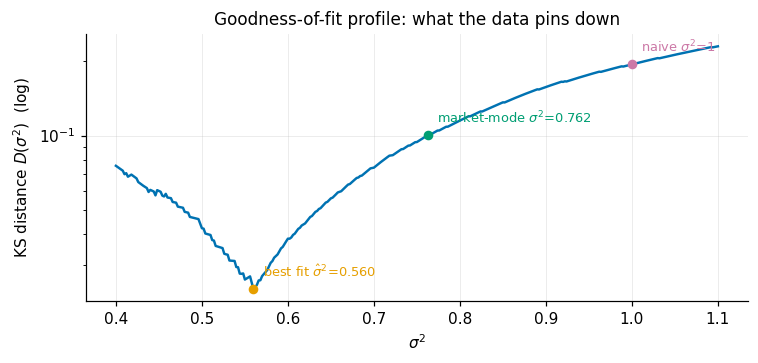

In [3]:
fig, ax = plt.subplots(figsize=(7.0, 3.4))
ax.plot(S2_GRID, D_profile, color=PALETTE[0], lw=1.6)
ax.set_yscale("log")
for s2v, Dv, lab, col in [(s2_fit, D_fit, f"best fit $\\hat\\sigma^2$={s2_fit:.3f}", PALETTE[1]),
                          (s2_mkt, D_mkt, f"market-mode $\\sigma^2$={s2_mkt:.3f}", PALETTE[2]),
                          (1.0, ks_bulk(lam, 1.0)[0], "naive $\\sigma^2$=1", PALETTE[3])]:
    ax.scatter([s2v], [Dv], color=col, zorder=3, s=28)
    ax.annotate(lab, xy=(s2v, Dv), xytext=(6, 8), textcoords="offset points",
                fontsize=8.5, color=col)
ax.set_xlabel("$\\sigma^2$"); ax.set_ylabel("KS distance $D(\\sigma^2)$  (log)")
ax.set_title("Goodness-of-fit profile: what the data pins down")
fig.tight_layout()
fig.savefig(DATA_DIR / "fig_phase2_s2_profile.png", dpi=200, bbox_inches="tight")
plt.show()

## 2. Figure 1 — the signature plot

Histogram of all eigenvalues against the MP density: naive $\sigma^2 = 1$ (dashed — visibly
too wide) and fitted $\hat\sigma^2$ (solid — tracking the bulk). Inset: the full spectrum on
a log axis, showing how far the signal modes sit from the band. Curves are scaled by the
bulk fraction $n_{\mathrm{bulk}}/N$ so histogram and density are directly comparable.

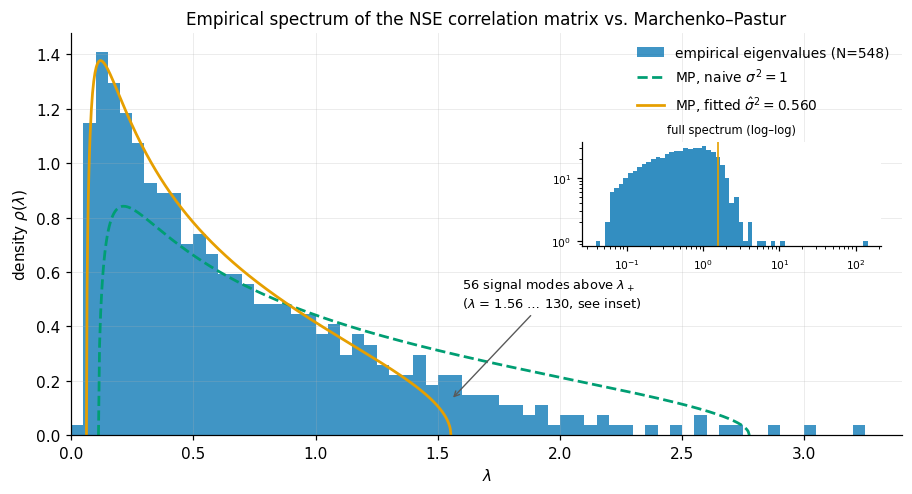

In [4]:
fig, ax = plt.subplots(figsize=(8.4, 4.6))

bins = np.linspace(0, 3.4, 69)
ax.hist(lam, bins=bins, density=True, color=PALETTE[0], alpha=0.75,
        label=f"empirical eigenvalues (N={N})")

for s2, color, ls, lab in [(1.0, PALETTE[2], "--", "MP, naive $\\sigma^2=1$"),
                           (s2_fit, PALETTE[1], "-", f"MP, fitted $\\hat\\sigma^2={s2_fit:.3f}$")]:
    lo, hi = mp_edges(s2)
    xg = np.linspace(lo + 1e-9, hi - 1e-9, 600)
    pdf = np.sqrt((hi - xg) * (xg - lo)) / (2 * np.pi * q * s2 * xg)
    frac = (lam <= hi).sum() / N
    ax.plot(xg, frac * pdf, color=color, ls=ls, lw=1.8, label=lab)

ax.annotate(f"{n_above_fit} signal modes above $\\lambda_+$\n"
            f"($\\lambda$ = {np.sort(lam[lam > hi_fit])[0]:.2f} … {lam[0]:.0f}, see inset)",
            xy=(hi_fit, 0.13), xytext=(1.60, 0.47),
            arrowprops=dict(arrowstyle="->", color="0.35", lw=0.9), fontsize=8.5)
ax.set_xlim(0, 3.4); ax.set_xlabel("$\\lambda$"); ax.set_ylabel("density $\\rho(\\lambda)$")
ax.set_title("Empirical spectrum of the NSE correlation matrix vs. Marchenko–Pastur")
ax.legend(frameon=False, fontsize=9, loc="upper right")

# inset: full range, log-x
axin = ax.inset_axes([0.615, 0.47, 0.36, 0.26])
axin.hist(lam, bins=np.logspace(np.log10(lam[-1] * 0.9), np.log10(lam[0] * 1.1), 60),
          color=PALETTE[0], alpha=0.8)
axin.axvline(hi_fit, color=PALETTE[1], lw=1.1, ls="-")
axin.set_xscale("log"); axin.set_yscale("log")
axin.tick_params(labelsize=7); axin.grid(False)
axin.set_title("full spectrum (log–log)", fontsize=7.5)

fig.tight_layout()
fig.savefig(DATA_DIR / "fig_phase2_mp_density.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. KS test with Monte Carlo calibration

For each of $M=200$ draws per null we regenerate the matrix, recompute the spectrum,
**re-fit $\sigma^2$ on the same grid**, and record the minimized $D$ — so the null
distribution reflects both the eigenvalue dependence and the flexibility gained by
fitting. The naive `kstwo` p-value is shown for reference only.

In [5]:
rng = np.random.default_rng(42)
M = 200

def spectrum_of(X):
    Xs = (X - X.mean(0)) / X.std(0, ddof=0)
    return np.linalg.eigvalsh((Xs.T @ Xs) / X.shape[0])

t0 = time.time()
D_gauss, s2_gauss = np.empty(M), np.empty(M)
for m in range(M):
    lam_sim = spectrum_of(rng.standard_normal((T, N)))
    s2_gauss[m], D_gauss[m] = fit_sigma2(lam_sim)
print(f"Gaussian-Wishart null: {time.time()-t0:.0f}s")

t0 = time.time()
D_perm, s2_perm = np.empty(M), np.empty(M)
for m in range(M):
    Rp = np.column_stack([rng.permutation(Rs[:, j]) for j in range(N)])
    lam_sim = spectrum_of(Rp)
    s2_perm[m], D_perm[m] = fit_sigma2(lam_sim)
print(f"permutation null: {time.time()-t0:.0f}s")

p_naive = kstwo.sf(D_fit, n_bulk)
p_gauss = (1 + (D_gauss >= D_fit).sum()) / (M + 1)
p_perm  = (1 + (D_perm  >= D_fit).sum()) / (M + 1)

print(f"\nobserved: D = {D_fit:.4f}  (n_bulk = {n_bulk}, fitted sigma2 = {s2_fit:.3f})")
print(f"naive KS p-value (reference only)       : {p_naive:.3g}")
print(f"MC p-value, Gaussian-Wishart null       : {p_gauss:.3f}   "
      f"(null D: median {np.median(D_gauss):.4f}, 95th pct {np.quantile(D_gauss, .95):.4f})")
print(f"MC p-value, permutation null            : {p_perm:.3f}   "
      f"(null D: median {np.median(D_perm):.4f}, 95th pct {np.quantile(D_perm, .95):.4f})")
print(f"null fitted sigma2: Gaussian {s2_gauss.mean():.3f} +/- {s2_gauss.std():.3f}, "
      f"permutation {s2_perm.mean():.3f} +/- {s2_perm.std():.3f}  (real data: {s2_fit:.3f})")

Gaussian-Wishart null: 29s
permutation null: 29s

observed: D = 0.0240  (n_bulk = 492, fitted sigma2 = 0.560)
naive KS p-value (reference only)       : 0.934
MC p-value, Gaussian-Wishart null       : 0.005   (null D: median 0.0051, 95th pct 0.0062)
MC p-value, permutation null            : 0.005   (null D: median 0.0052, 95th pct 0.0061)
null fitted sigma2: Gaussian 1.000 +/- 0.002, permutation 1.000 +/- 0.002  (real data: 0.560)


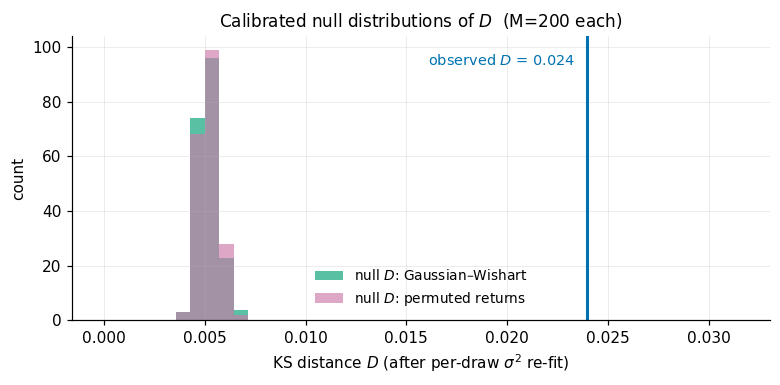

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.6))
b = np.linspace(0, max(D_fit * 1.25, D_gauss.max(), D_perm.max()) * 1.05, 45)
ax.hist(D_gauss, bins=b, alpha=0.65, color=PALETTE[2], label="null $D$: Gaussian–Wishart")
ax.hist(D_perm, bins=b, alpha=0.65, color=PALETTE[3], label="null $D$: permuted returns")
ax.axvline(D_fit, color=PALETTE[0], lw=2)
ax.annotate(f"observed $D$ = {D_fit:.3f}", xy=(D_fit, ax.get_ylim()[1]*0.9),
            xytext=(-8, 0), textcoords="offset points", ha="right",
            color=PALETTE[0], fontsize=9.5)
ax.set_xlabel("KS distance $D$ (after per-draw $\\sigma^2$ re-fit)")
ax.set_ylabel("count"); ax.legend(frameon=False, fontsize=9)
ax.set_title(f"Calibrated null distributions of $D$  (M={M} each)")
fig.tight_layout()
fig.savefig(DATA_DIR / "fig_phase2_ks_null.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Persist results for Phases 3–4

Phase 3 unfolds the bulk with this fitted MP law; Phase 4's filtering rule uses
$\lambda_+(\hat\sigma^2)$ as its threshold.

In [7]:
results = {
    "q": q, "N": N, "T": T,
    "sigma2_naive": 1.0,
    "sigma2_market": round(float(s2_mkt), 6),
    "sigma2_fit": round(float(s2_fit), 6),
    "fixed_point_iteration": "unstable (runs to 0): no sharp spike/bulk separation",
    "band_fit": [round(float(lo_fit), 6), round(float(hi_fit), 6)],
    "band_market": [round(float(lo_mkt), 6), round(float(hi_mkt), 6)],
    "n_bulk": int(n_bulk), "n_above": int(n_above_fit),
    "n_above_market": int(n_above_mkt),
    "n_below_band": int((lam < lo_fit).sum()),
    "KS_D": round(float(D_fit), 6), "KS_D_market": round(float(D_mkt), 6),
    "p_naive": float(p_naive),
    "p_MC_gaussian": round(float(p_gauss), 4), "p_MC_permutation": round(float(p_perm), 4),
    "M_sims": M, "s2_grid": [0.40, 1.10, 0.002],
}
(DATA_DIR / "mp_fit_results.json").write_text(json.dumps(results, indent=2))
print(json.dumps(results, indent=2))

{
  "q": 0.44336569579288027,
  "N": 548,
  "T": 1236,
  "sigma2_naive": 1.0,
  "sigma2_market": 0.762344,
  "sigma2_fit": 0.56,
  "fixed_point_iteration": "unstable (runs to 0): no sharp spike/bulk separation",
  "band_fit": [
    0.062525,
    1.554045
  ],
  "band_market": [
    0.085117,
    2.115566
  ],
  "n_bulk": 492,
  "n_above": 56,
  "n_above_market": 22,
  "n_below_band": 6,
  "KS_D": 0.023964,
  "KS_D_market": 0.100058,
  "p_naive": 0.9335966941900566,
  "p_MC_gaussian": 0.005,
  "p_MC_permutation": 0.005,
  "M_sims": 200,
  "s2_grid": [
    0.4,
    1.1,
    0.002
  ]
}


In [8]:
verdict_g = "cannot be rejected" if p_gauss >= 0.05 else "is rejected"
verdict_p = "cannot be rejected" if p_perm >= 0.05 else "is rejected"

draft = f'''We compare the empirical spectrum of the sample correlation matrix against the
Marchenko-Pastur density with the variance parameter determined from the data itself,
since the signal modes absorb a large share of the trace and compress the noise bulk
to an effective variance below one. The conservative market-mode convention
sigma2_mkt = 1 - lambda_1/N = {s2_mkt:.3f} yields the band
[{lo_mkt:.3f}, {hi_mkt:.3f}] with {n_above_mkt} eigenvalues above it, while the
KS-minimizing fit sigma2_hat = {s2_fit:.3f} yields [{lo_fit:.3f}, {hi_fit:.3f}]
with {n_above_fit} above. The gap between the two is informative: a fully
self-consistent determination (subtracting all above-band variance and iterating)
is unstable on our data, running away toward zero -- the spectrum exhibits no sharp
spike/bulk separation but a shoulder of group modes grading into the bulk, and we
therefore report the full goodness-of-fit profile D(sigma2) rather than a single
canonical band, carrying both thresholds into the filtering experiments.
At the optimum, the KS distance between the {n_bulk} bulk eigenvalues and the MP law
is D = {D_fit:.4f} -- visually the density overlay is excellent, and the naive
p-value (0.93) would suggest a comfortable fit. That number is however meaningless
for eigenvalues, and in an instructive direction: because of spectral rigidity
(level repulsion), a true noise spectrum hugs the MP law far more tightly than an
i.i.d. sample of the same size ever would. Calibrating D by Monte Carlo -- re-fitting
sigma2 on each of M = {M} draws -- the null distribution of D concentrates around
{np.median(D_gauss):.4f}, and the observed {D_fit:.4f} sits far in its tail:
p = {p_gauss:.3f} under a Gaussian-Wishart null and p = {p_perm:.3f} under a
permutation null that retains each stock's fat-tailed marginal while destroying all
cross-correlation. At the 5% level, exact MP-ness of the bulk {verdict_g} under the
Gaussian null and {verdict_p} under the permutation null. We interpret this as
N = {N} giving the test power against the small, well-documented corrections to MP
in financial data (autocorrelation, heteroskedasticity, non-stationarity) rather
than as evidence of exploitable structure: the deviations are of a few percent in
CDF (D = {D_fit:.3f}), the fitted-sigma2 null distributions concentrate at 1
(Gaussian {s2_gauss.mean():.3f}, permutation {s2_perm.mean():.3f}) confirming the
bulk compression is real, and whether the bulk carries usable information is tested
directly by the spacing statistics (Section 5.2) and the out-of-sample backtest
(Section 5.4).'''

print(draft)
(DATA_DIR / "section51_mp_draft.md").write_text(draft)
print("\nsaved -> data/section51_mp_draft.md")

We compare the empirical spectrum of the sample correlation matrix against the
Marchenko-Pastur density with the variance parameter determined from the data itself,
since the signal modes absorb a large share of the trace and compress the noise bulk
to an effective variance below one. The conservative market-mode convention
sigma2_mkt = 1 - lambda_1/N = 0.762 yields the band
[0.085, 2.116] with 22 eigenvalues above it, while the
KS-minimizing fit sigma2_hat = 0.560 yields [0.063, 1.554]
with 56 above. The gap between the two is informative: a fully
self-consistent determination (subtracting all above-band variance and iterating)
is unstable on our data, running away toward zero -- the spectrum exhibits no sharp
spike/bulk separation but a shoulder of group modes grading into the bulk, and we
therefore report the full goodness-of-fit profile D(sigma2) rather than a single
canonical band, carrying both thresholds into the filtering experiments.
At the optimum, the KS distance between the

## What to write where

- **Section 5.1:** the draft above + Figure 1 (`fig_phase2_mp_density.png`) and the
  calibration figure (`fig_phase2_ks_null.png`).
- **Methodology (Section 3):** the two-way determination of $\sigma^2$ and the MC
  calibration protocol — both are answers to referee objections *before they are raised*.
- **Interpretation guardrails:** if the calibrated tests reject, the correct claim is not
  "the bulk is exactly MP" but "the bulk is well-described by MP with small quantified
  deviations ($D \approx$ a few percent), consistent with known finite-$T$ corrections
  (autocorrelation, heteroskedasticity, non-stationarity)" — the *economic* conclusion
  that in-band modes carry no exploitable cross-sectional structure is tested directly
  by the spacing statistics (Phase 3) and the out-of-sample backtest (Phase 7).